# Packages, constants, and useful routines

In [17]:
import numpy as np
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.optimize import minimize

deg = np.pi/180
rad = 1/deg

def axis_equal(fig):
  # Calculate the range for all axes using fig.data, excluding sphere data
  x_data = [trace.x for trace in fig.data if isinstance(trace, go.Scatter3d)]
  y_data = [trace.y for trace in fig.data if isinstance(trace, go.Scatter3d)]
  z_data = [trace.z for trace in fig.data if isinstance(trace, go.Scatter3d)]
  if len(x_data)==0:
    return
  x_data = np.concatenate(x_data)
  y_data = np.concatenate(y_data)
  z_data = np.concatenate(z_data)
  max_range = np.array([x_data.max()-x_data.min(), y_data.max()-y_data.min(), z_data.max()-z_data.min()]).max() / 2.0
  mid_x = (x_data.max()+x_data.min()) * 0.5
  mid_y = (y_data.max()+y_data.min()) * 0.5
  mid_z = (z_data.max()+z_data.min()) * 0.5
  fig.update_layout(scene=dict(aspectmode='cube', xaxis=dict(range=[mid_x - max_range, mid_x + max_range]), yaxis=dict(range=[mid_y - max_range, mid_y + max_range]), zaxis=dict(range=[mid_z - max_range, mid_z + max_range])))

def fig_body(R, mesh3d_opts=dict(), lighting_opts=dict()):
  # Default options
  mesh3d_opts_def = dict(color='lightblue', opacity=0.5, alphahull=0)
  mesh3d_opts_def.update(mesh3d_opts)
  lighting_opts_def = dict(ambient=0.5, specular=1.0)
  lighting_opts_def.update(lighting_opts)
  # Sphere
  d=np.pi/32
  theta, phi = np.mgrid[0:np.pi+d:d, 0:2*np.pi:d]
  x = np.sin(theta) * np.cos(phi)
  y = np.sin(theta) * np.sin(phi)
  z = np.cos(theta)
  points = R*np.vstack([x.ravel(), y.ravel(), z.ravel()])
  x, y, z = points
  fig = go.Figure(data=[go.Mesh3d(x=x, y=y, z=z, **mesh3d_opts_def)])
  fig.update_traces(lighting=lighting_opts_def)
  return fig

tau = 0
encendido = 0
teta = 0 # Polar angle relative to the velocity vector
phi = 0 # Azimuthal angle relative to a plane containing the velocity vector and the x-axis

def aceleracion_empuje_general(simulacion):
    global tau,encendido,teta,phi
    if not encendido:
        return
    # Retrieve all simulation data
    sim = simulacion.contents
    p = sim.particles[1]
    # Position, velocity, and specific angular momentum (normal to the orbit)
    rvec = np.array(p.xyz)
    r = np.linalg.norm(rvec)
    vvec = np.array(p.vxyz)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)
    # Calculate the thrust direction using velocity as the reference
    uvel_z = vvec / v
    uvel_x = hvec / np.linalg.norm(hvec)
    uvel_y = np.cross(uvel_z, uvel_x)
    tvec = tau * (np.cos(teta)*uvel_z + np.sin(teta)*np.cos(phi)*uvel_x + np.sin(teta)*np.sin(phi)*uvel_y)
    # Modify the particle acceleration
    p.ax += tvec[0]
    p.ay += tvec[1]
    p.az += tvec[2]

def mision_general(m,units,orbita_inicial,maniobras,bodies=[]):
    """General mission design routine."""
    global tau,encendido,teta,phi
    # Define the simulation
    sim = rb.Simulation()
    sim.units = units
    sim.add(m=m)
    sim.add(m=0,**orbita_inicial)
    for body in bodies:
        sim.add(**body)
    sim.move_to_com()
    sim.additional_forces = aceleracion_empuje_general
    sim.force_is_velocity_dependent = True
    Xms = []
    Ems = []
    tms = []
    Xbodies = []
    t = 0
    # Initial position
    o=sim.orbits()[0]
    Xs = [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
    Es = [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
    Xms += [np.array(Xs)]
    Ems += [np.array(Es)]
    tms += [t]
    for maniobra in maniobras:
        if maniobra['tipo'] == 'inercial':
            P = sim.particles[1].P
            # Select the deltat units
            if ('tunit' in maniobra.keys()) and maniobra['tunit']=='P':
              deltat = maniobra['deltat']*abs(P)
            else:
              deltat = maniobra['deltat']
            ts = np.linspace(t, t + deltat, maniobra['N'])
            Xs = []
            Es = []
            for t_step in ts:
                sim.integrate(t_step)
                o=sim.orbits()[0]
                Xs += [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
                Es += [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
                Xb = []
                for n in range(2,sim.N):
                  Xb += [list(sim.particles[n].xyz)+list(sim.particles[n].vxyz)]
                Xbodies += [np.array(Xb)]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [ts]
            t = ts[-1] # Update the current time
        elif maniobra['tipo'] == 'impulsiva':
            sim.particles[1].vxyz += maniobra['deltav']
            o=sim.orbits()[0]
            Xs = [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
            Es = [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
            Xb = []
            for n in range(2,sim.N):
              Xb += [list(sim.particles[n].xyz)+list(sim.particles[n].vxyz)]
            Xbodies += [np.array(Xb)]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [sim.t]
        elif maniobra['tipo'] == 'impulsada':
            P = sim.particles[1].P
            # Select the deltat units
            if ('tunit' in maniobra.keys()) and maniobra['tunit']=='P':
              deltat = maniobra['deltat']*abs(P)
            else:
              deltat = maniobra['deltat']
            tau = maniobra['tau']
            teta = maniobra.get('teta', 0) # Default to 0 if not provided
            phi = maniobra.get('phi', 0)   # Default to 0 if not provided
            encendido = True
            ts = np.linspace(t, t + deltat, maniobra['N'])
            Xs = []
            Es = []
            for t_step in ts:
                sim.integrate(t_step)
                o=sim.orbits()[0]
                Xs += [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
                Es += [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
                Xb = []
                for n in range(2,sim.N):
                  Xb += [list(sim.particles[n].xyz)+list(sim.particles[n].vxyz)]
                Xbodies += [np.array(Xb)]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [ts]
            encendido = 0
            t = ts[-1] # Update the current time
        else:
            raise Exception('Unrecognized maneuver type')
    Xbodies = np.array(Xbodies)
    if len(bodies) > 0:
      return maniobras, tms, Xms, Ems, Xbodies
    else:
      return maniobras, tms, Xms, Ems

def dibuja_mision(fig, mision):
  if len(mision) == 4:
    maniobras, tms, Xms, Ems = mision
    qbodies = False
  else:
    maniobras, tms, Xms, Ems, Xbodies = mision
    qbodies = True
  colors = ['blue', 'red', 'green', 'purple', 'orange']
  # First point
  segment=Xms[0]
  fig.add_trace(go.Scatter3d(x=[segment[0, 0]], y=[segment[0, 1]], z=[segment[0, 2]], mode='markers', marker=dict(color='black', symbol='circle', size=2), name='Initial', showlegend=True))
  for i, segment in enumerate(Xms[1:]):
      maniobra = maniobras[i]
      if maniobra['tipo'] == 'inercial':
        fig.add_trace(go.Scatter3d(x=segment[:, 0], y=segment[:, 1], z=segment[:, 2], mode='lines', line=dict(color=colors[i % len(colors)]), name=f'Inertial {i+1}'))
      if maniobra['tipo'] == 'impulsada':
        fig.add_trace(go.Scatter3d(x=segment[:, 0], y=segment[:, 1], z=segment[:, 2], mode='lines', line=dict(color=colors[i % len(colors)]), name=f'Powered {i+1}'))
        # Draw thrust
        N = maniobra['N']
        for j in range(len(segment))[::int(N/10)]:
          vvec = segment[j,3:]
          v = np.linalg.norm(vvec)
          rvec = segment[j,:3]
          r = np.linalg.norm(rvec)
          hvec = np.cross(rvec, vvec)
          # Calculate the thrust direction
          uvel_z = vvec / v
          uvel_x = hvec / np.linalg.norm(hvec)
          uvel_y = np.cross(uvel_z, uvel_x)
          tvec = 0.1*r*(np.cos(teta)*uvel_z + np.sin(teta)*np.cos(phi)*uvel_x + np.sin(teta)*np.sin(phi)*uvel_y)
          fig.add_trace(go.Scatter3d(x=[segment[j, 0], segment[j, 0] + tvec[0]], y=[segment[j, 1], segment[j, 1] + tvec[1]], z=[segment[j, 2], segment[j, 2] + tvec[2]], mode='lines', line=dict(color='black', width=2), showlegend=False))
      if maniobra['tipo'] == 'impulsiva':
        fig.add_trace(go.Scatter3d(x=segment[:, 0], y=segment[:, 1], z=segment[:, 2], mode='markers', marker=dict(color='black', symbol='diamond',size=3), showlegend=False))
        distance = np.linalg.norm(segment[0, :3])
        scalev = np.linalg.norm(segment[:,3:],axis=1).mean()
        deltav = maniobras[i]['deltav']/scalev*distance*0.5
        fig.add_trace(go.Scatter3d(x=[segment[0, 0], segment[0, 0] + deltav[0]], y=[segment[0, 1], segment[0, 1] + deltav[1]], z=[segment[0, 2], segment[0, 2] + deltav[2]], mode='lines', line=dict(color='black', width=2), name=f'Impulsive {i+1}', showlegend=True))
  if qbodies:
    Nbodies = Xbodies.shape[1]
    for n in range(Nbodies):
      fig.add_trace(go.Scatter3d(x=Xbodies[:,n,0], y=Xbodies[:,n,1], z=Xbodies[:,n,2], mode='lines', line=dict(color='black', width=2), name=f'Body {n+1}', showlegend=True))
  fig.update_layout(legend=dict(y=0.5,yanchor='bottom'))

In [18]:
import spiceypy as spy
import os
import urllib.request

KERNEL_DIR = "kernels"
os.makedirs(KERNEL_DIR, exist_ok=True)

kernels = {
    "naif0012.tls": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls",
    "de430.bsp":    "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de430.bsp",
}

for fname, url in kernels.items():
    path = os.path.join(KERNEL_DIR, fname)
    if not os.path.exists(path):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, path)
    spy.furnsh(path)

print("Kernels Correctly Loaded.")

Kernels Correctly Loaded.


# Lunar trajectories

In [4]:
rp = 363400 * 1e3                  # In m
ra = 405500 * 1e3                  # In m
mue = pc.constantes.mu_earth

In [5]:
a = (rp + ra) / 2
e = (ra - rp) / (rp + ra)
T = 2 * np.pi * np.sqrt(a**3 / mue)

a, e, T

(384450000.0, 0.05475354402393029, np.float64(2372306.407053572))

In [6]:
T / 86400

np.float64(27.457250081638566)

Get data directly from SPICE

In [14]:
def consulta_posicion(id, location, epoch):
    if isinstance(epoch, str):
        et = spy.str2et(epoch)
    else:
        et = spy.unitim(epoch, 'JDTDB', 'ET')

    estado, lt = spy.spkezr(id, et, 'ECLIPJ2000', 'NONE', location)
    Xs = np.array(estado) * 1000 
    jd = spy.unitim(et, 'ET', 'JDTDB')
    return Xs, jd

In [19]:
Xs_moon, jd = consulta_posicion('301', '399', '2026-02-01 12:00:00')
Xs_moon

array([-2.20809191e+08,  2.96289934e+08,  1.78812496e+07, -8.76407748e+02,
       -6.02698273e+02, -8.02929198e+01])

This position is in the ecliptic coordinate system.

In [20]:
Xs_moon, jd = consulta_posicion('301', '399', '2020-05-04 12:00:00')
Xs_moon[:3]/1e3

array([-359978.1297575 ,  -17129.21466921,   32337.17569392])

This discrepancy may be because the book uses the J2000 system.

To convert from ECLIPJ2000 to J2000

In [21]:
et = spy.unitim(jd, 'JDTDB', 'ET')
M_ecl2equ = spy.pxform('ECLIPJ2000', 'J2000', 0)  # matriz fija, no depende de et
r_moon = spy.mxv(M_ecl2equ, Xs_moon[:3])
v_moon = spy.mxv(M_ecl2equ, Xs_moon[3:])
r_moon/1e3, v_moon/1e3

(array([-359978.1297575 ,  -28578.73697473,   22855.16834269]),
 array([ 0.08079241, -0.99022124, -0.43754055]))

Moon's path during one month

Returning to the Artemis II case

In [22]:
Xs_moon, jd = consulta_posicion('301', '399', '2026-02-01 12:00:00')
Xs_moon

array([-2.20809191e+08,  2.96289934e+08,  1.78812496e+07, -8.76407748e+02,
       -6.02698273e+02, -8.02929198e+01])

In [23]:
jds = np.linspace(jd, jd + 100 * 365.25, 1000)
ds = []
rps = []
Is = []

for jdt in jds:
    Xs_moon, jdt = consulta_posicion('301', '399', jdt)
    r_moon = spy.mxv(M_ecl2equ, Xs_moon[:3])
    v_moon = spy.mxv(M_ecl2equ, Xs_moon[3:])
    Xs_moon = np.concatenate([r_moon, v_moon])

    elementos = spy.oscelt(Xs_moon, 0, mue)

    rps += [elementos[0]]
    Is += [elementos[2] * rad]
    ds += [np.linalg.norm(r_moon)]

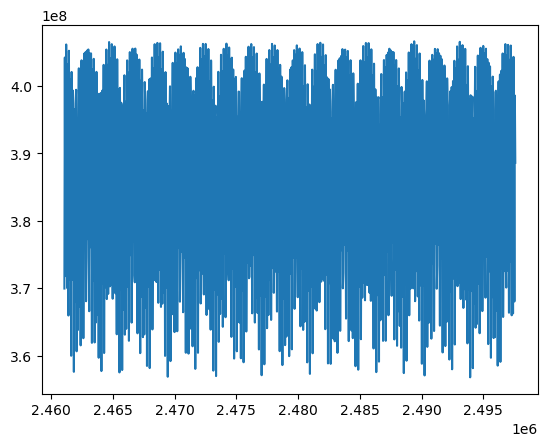

In [24]:
pio.renderers.default = "png"
plt.plot(jds, ds)

In [25]:
min(ds), max(ds)

(np.float64(356786907.7862864), np.float64(406617373.8789443))

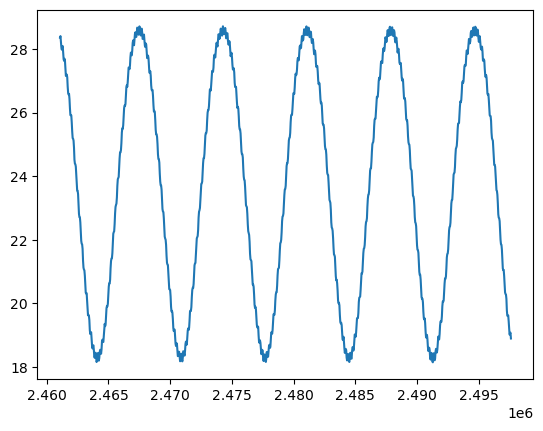

In [26]:
pio.renderers.default = "png"
plt.plot(jds, Is)

In [27]:
np.mean(rps)

np.float64(366481403.81239897)

Let's calculate the average lunar velocity assuming a circular orbit:

In [28]:
vm = np.sqrt(mue / a)
a, vm

(384450000.0, np.float64(1018.2371822471931))

## Hohmann transfer to the Moon

Assuming a given departure orbit:

In [29]:
km = 1e3

In [30]:
z = 320 * km
rc = 6378 * km + z
vc = np.sqrt(mue / rc)
ve = np.sqrt(2 * mue / rc)

rc, vc, ve

(6698000.0, np.float64(7714.296248071876), np.float64(10909.66237818713))

Transfer orbit properties:

In [31]:
r1 = rc           # Parking orbit radius
r2 = 384400 * km  # Moon's semi-major axis

eH = (r2 - r1) / (r2 + r1)
aH = (r1 + r2) / 2
TH = 2 * np.pi * np.sqrt(aH**3 / mue)
tH = TH / 2
h = np.sqrt(2 * mue) * np.sqrt((r1 * r2) / (r1 + r2))

eH, aH / km, TH / 3600, tH / 3600, h/km**3

(0.9657477154063687,
 195549.0,
 np.float64(239.05172518239522),
 np.float64(119.52586259119761),
 np.float64(72.44448773907375))

In [32]:
r1

6698000.0

In [33]:
rp = r1
ra = r2
vp = h / rp
va = h / ra

In [34]:
deltav1 = vp - vc
deltav2 = vm - va
deltav1 / km, deltav2 / km

(np.float64(3.1015424708104384), np.float64(0.8297759758500189))

In [35]:
deltav_tot = deltav1 + deltav2
deltav_tot / 1e3

np.float64(3.931318446660457)

## I want to arrive sooner

In [36]:
vp, tH/86400

(np.float64(10815.838718882314), np.float64(4.980244274633233))

In [37]:
kms = 1e3
vpm = 10.85 * kms

In [38]:
h = vpm * rp
h/kms**2

72673.3

In [39]:
em = h**2 / mue / rp - 1   # rp = p / (1 - e)
em

0.978184755360491

In [40]:
am = (h**2/mue) / (1 - em**2)
am / km

307032.9996606792

True anomaly at the intersection with the lunar orbit:

In [41]:
theta = np.arccos((h**2 / mue / r2 - 1 ) / em)
theta*rad

np.float64(170.77415636063427)

In [42]:
E = 2 * np.arctan(np.sqrt((1 - em)/ (1 + em)) * np.tan(theta/2))
E*rad

np.float64(104.92784123789005)

In [43]:
M = E - em * np.sin(E)
M * rad

np.float64(50.773473773897045)

In [44]:
Tm = 2 * np.pi * np.sqrt(am**3 / mue)
n = 2 * np.pi / Tm
tF = M / n
Tm/3600, tF/3600, tF/86400

(np.float64(470.31200721997516),
 np.float64(66.33159545592302),
 np.float64(2.763816477330126))

Arrival velocity:

In [45]:
vr = mue / h * em * np.sin(theta)
vperp = h / r2
vr/kms, vperp/kms

(np.float64(0.8601791043418741), 0.18905645161290324)

In [46]:
varr = np.sqrt(vr**2 + vperp**2)
varr

np.float64(880.7101869757445)

In [47]:
gamma = np.arctan(vr / vperp)
gamma*rad

np.float64(77.60420563609443)

In [48]:
deltavf = np.sqrt(vm**2 + varr**2 - 2*vm*varr*np.cos(gamma))
deltavf/kms

np.float64(1.1947588775989921)

In [49]:
deltav1m = vpm - vc
deltav2m = deltavf

deltav_tot_m = deltav1m + deltav2m
deltav_tot_m / kms

np.float64(4.330462629527116)

Only increasing by 400 m/s reduces the travel time by 2 days

## Modeling a one-way orbit to the Moon

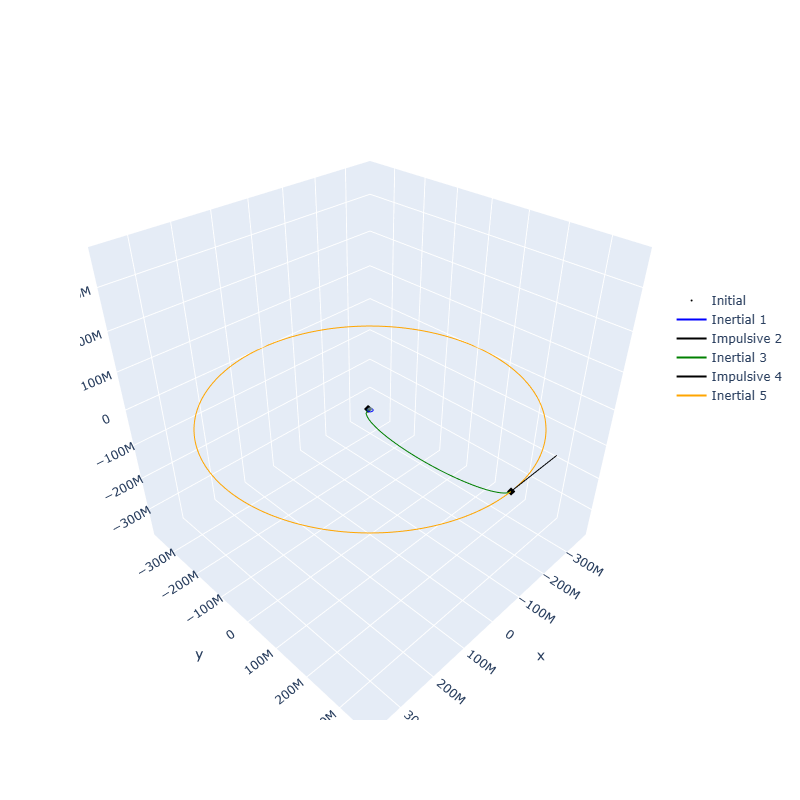

In [50]:
N = 100

mision = mision_general(
    m=pc.constantes.M_earth,
    units=('m','s','kg'),
    orbita_inicial=dict(
        x=0,y=-r1,z=0,
        vx=vc,vy=0,vz=0),
    maniobras=[
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([deltav1,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=1/2, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([-deltav2,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N)
    ],
)
maniobras, tms, Xms, Ems = mision
pio.renderers.default = "png"
fig = go.Figure()
fig = fig_body(6378*km)
dibuja_mision(fig, mision)
axis_equal(fig)
fig.update_layout(width=800,height=800)
fig.show()

Modified:

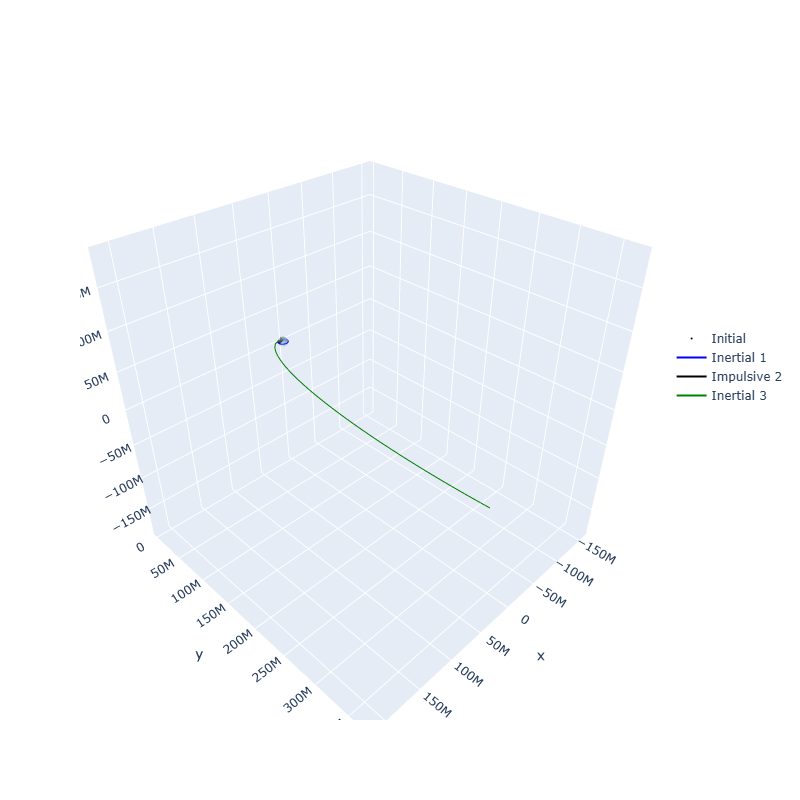

In [51]:
N = 100

mision = mision_general(
    m=pc.constantes.M_earth,
    units=('m','s','kg'),
    orbita_inicial=dict(
        x=0,y=-r1,z=0,
        vx=vc,vy=0,vz=0),
    maniobras=[
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([deltav1m,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=tF,N=2*N),
        #dict(tipo='impulsiva', deltav=np.array([-deltav2,0,0])), # Correction maneuver
        #dict(tipo='inercial',deltat=1, tunit='P',N=2*N)
    ],
)
maniobras, tms, Xms, Ems = mision
pio.renderers.default = "png"
fig = go.Figure()
fig = fig_body(6378*km)
dibuja_mision(fig, mision)
axis_equal(fig)
fig.update_layout(width=800,height=800)
fig.show()

In [52]:
r_vec_ini = np.array([-5914.0e3, -3144.5e3, 0])
v_vec_ini = np.array([4.0556e3, -10.037e3, 0])

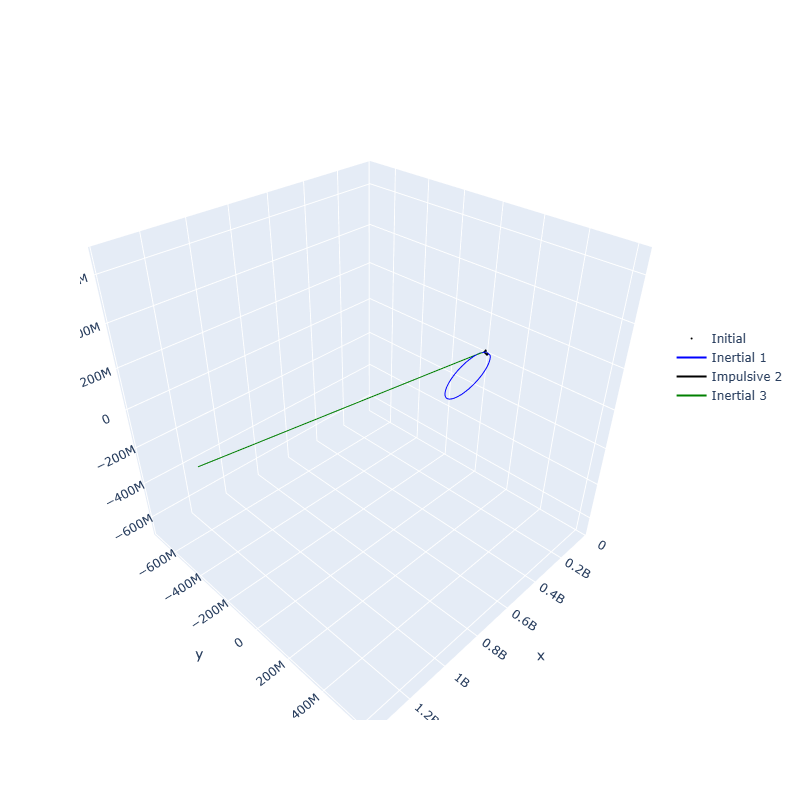

In [53]:
N = 100

mision = mision_general(
    m=pc.constantes.M_earth,
    units=('m','s','kg'),
    orbita_inicial=dict(
        x=r_vec_ini[0],y=r_vec_ini[1],z=r_vec_ini[2],
        vx=v_vec_ini[0],vy=v_vec_ini[1],vz=v_vec_ini[2]),
    maniobras=[
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([deltav1m,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=tF,N=2*N),
        #dict(tipo='impulsiva', deltav=np.array([-deltav2,0,0])), # Correction maneuver
        #dict(tipo='inercial',deltat=1, tunit='P',N=2*N)
    ],
)
maniobras, tms, Xms, Ems = mision
pio.renderers.default = "png"
fig = go.Figure()
fig = fig_body(6378*km)
dibuja_mision(fig, mision)
axis_equal(fig)
fig.update_layout(width=800,height=800)
fig.show()

## Artemis II

In [54]:
zart = 185 * km
Tart = 24 * 3600
aart = (mue/(2 * np.pi / Tart)**2) ** (1/3)
rpart =6378 * km + zart
aart

42241095.4519603

In [55]:
rpart =6378 * km + zart
eart = 1 - rpart / aart
raart = aart * (1 + eart)
eart

0.8446299763351561

In [56]:
hart = ((2 * mue)**0.5) * ((rpart * raart) / (rpart + raart))**0.5
hart/km**3

69.46638796646712

In [57]:
vart = hart / rpart
vart

10584.547915049081

In [58]:
veart = np.sqrt(2 * mue / rpart)
veart


np.float64(11021.296347759131)

For the transfer orbit:

In [59]:
r1art = rpart           # Parking orbit radius
r2art = 384400 * km  # Moon's semi-major axis

eHart = (r2art - r1art) / (r2art + r1art)
aH = (r1art + r2art) / 2
THart = 2 * np.pi * np.sqrt(aH**3 / mue)
tHart = THart / 2
hHart = np.sqrt(2 * mue) * np.sqrt((r1art * r2art) / (r1art + r2art))

eHart, aH / km, THart / 3600, tHart / 86400, hHart/km**3

(0.966426490486312,
 195481.5,
 np.float64(238.9279613259745),
 np.float64(4.977665860957802),
 np.float64(71.72308222217424))

In [60]:
rpart_t = r1art
raart_t = r2art
vpart_t = hHart / rpart_t
vaart_t = hHart / raart_t

rpart_t, raart_t, vpart_t, vaart_t

(6563000.0,
 384400000.0,
 np.float64(10928.398936793272),
 np.float64(186.58450109826805))

In [61]:
deltav1_art = vpart_t - vart
deltav2_art = vm - vaart_t
deltav1_art / km, deltav2_art / km

(np.float64(0.3438510217441908), np.float64(0.831652681148925))

In [62]:
deltav_tot_art = deltav1_art + deltav2_art
deltav_tot_art / 1e3

np.float64(1.175503702893116)

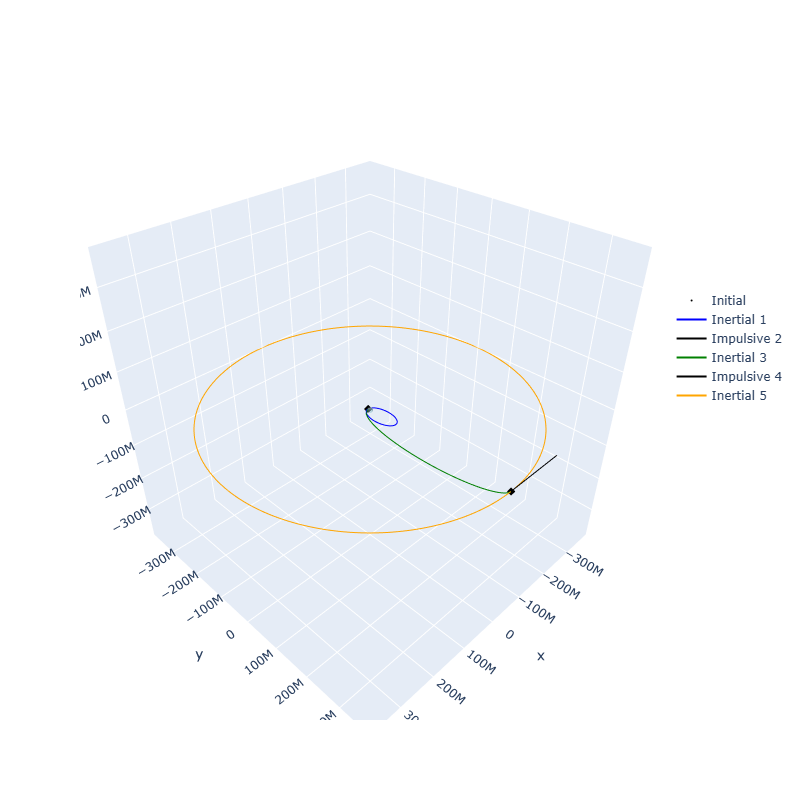

In [63]:
N = 100

mision = mision_general(
    m=pc.constantes.M_earth,
    units=('m','s','kg'),
    orbita_inicial=dict(
        x=0,y=-r1art,z=0,
        vx=vart,vy=0,vz=0),
    maniobras=[
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([deltav1_art,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=1/2, tunit='P',N=2*N),
        dict(tipo='impulsiva', deltav=np.array([-deltav2_art,0,0])), # Correction maneuver
        dict(tipo='inercial',deltat=1, tunit='P',N=2*N)
    ],
)
maniobras, tms, Xms, Ems = mision
pio.renderers.default = "png"
fig = go.Figure()
fig = fig_body(6378*km)
dibuja_mision(fig, mision)
axis_equal(fig)
fig.update_layout(width=800,height=800)
fig.show()

**Modified:**

In [64]:
vpart_t/km, tHart/86400

(np.float64(10.928398936793272), np.float64(4.977665860957802))

In [65]:
vpartm = 10.95 * kms

In [66]:
hartm = vpartm * rpart_t
hartm/kms**2

71864.85

In [67]:
eartm = hartm**2 / mue / rpart_t - 1   # rp = p / (1 - e)
eartm

0.9742078467603192

In [68]:
aartm = (hart**2/mue) / (1 - eartm**2)
aartm / km

237755.83927749482

In [69]:
theta_art = np.arccos((hartm**2 / mue / r2 - 1 ) / eartm)
theta_art*rad

np.float64(172.69180620476018)

In [70]:
Eart = 2 * np.arctan(np.sqrt((1 - eartm)/ (1 + eartm)) * np.tan(theta_art/2))
Eart*rad

np.float64(121.61348233554729)

In [71]:
Mart = Eart - eartm * np.sin(Eart)
Mart * rad

np.float64(74.07867369922756)

In [72]:
Tartm = 2 * np.pi * np.sqrt(aartm**3 / mue)
nart = 2 * np.pi / Tartm
tartF = Mart / nart
Tartm/3600, tartF/3600, tartF/86400

(np.float64(320.4832020593091),
 np.float64(65.94714042065326),
 np.float64(2.747797517527219))

In [73]:
vr_art = mue / hartm * eartm * np.sin(theta_art)
vperp_art = hartm / r2art
vr_art/kms, vperp_art/kms

(np.float64(0.6873564697631479), 0.1869533038501561)

In [74]:
varr_art = np.sqrt(vr_art**2 + vperp_art**2)
varr_art

np.float64(712.3274909378031)

In [75]:
gamma_art = np.arctan(vr_art / vperp_art)
gamma_art*rad

np.float64(74.78426750038388)

In [76]:
deltavf_art = np.sqrt(vm**2 + varr_art**2 - 2*vm*varr_art*np.cos(gamma_art))
deltavf_art/kms

np.float64(1.0786527722154506)

In [77]:
deltav1m_art = vpartm - vart
deltav2m_art = deltavf_art

deltav_tot_m_art = deltav1m_art + deltav2m_art
deltav_tot_m_art / kms

np.float64(1.4441048571663695)

Plot for different Vp values, from the original value to escape velocity:

In [78]:
vpartms = np.linspace(vpart_t, veart, 1000)
tartF_ms = []
deltav_tot_m = []

for vpm in vpartms:

    hartm = vpm * rpart_t
    eartm = hartm**2 / (mue * rpart_t) - 1
    aartm = hartm**2 / (mue * (1 - eartm**2))

    theta_art = np.arccos((hartm**2 / (mue * r2) - 1) / eartm)
    Eart = 2 * np.arctan(np.sqrt((1 - eartm)/(1 + eartm)) * np.tan(theta_art / 2))
    Mart = Eart - eartm * np.sin(Eart)


    Tartm = 2 * np.pi * np.sqrt(aartm**3 / mue)
    nart = 2 * np.pi / Tartm
    tartFm = Mart / nart
    tartF_ms.append(tartFm)

    vr_art = mue / hartm * eartm * np.sin(theta_art)
    vperp_art = hartm / r2
    varr_art = np.sqrt(vr_art**2 + vperp_art**2)

    deltavf_art = np.sqrt(vm**2 + varr_art**2 - 2 * vm * varr_art * np.cos(gamma_art))
    deltav1m_art = vpm - vart
    deltav_tot_m.append(deltav1m_art + deltavf_art)

tartF_ms = np.array(tartF_ms)
deltav_tot_m = np.array(deltav_tot_m)


C:\Users\User\AppData\Local\Temp\ipykernel_13260\1862102687.py:11: RuntimeWarning: invalid value encountered in arccos
  theta_art = np.arccos((hartm**2 / (mue * r2) - 1) / eartm)


Plots for total $\Delta V$:

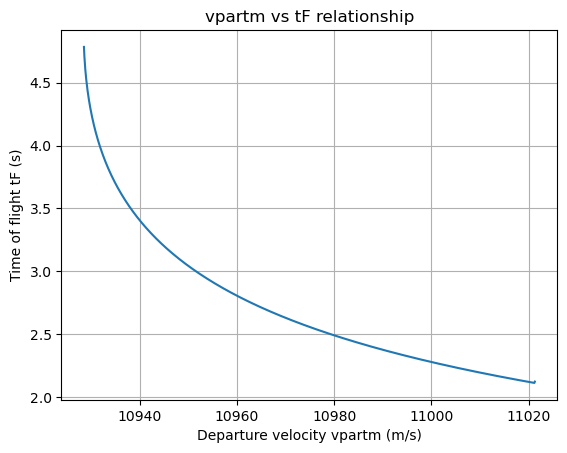

In [79]:
pio.renderers.default = "png"
plt.figure()
plt.plot(vpartms, tartF_ms/86400)
plt.xlabel('Departure velocity vpartm (m/s)')
plt.ylabel('Time of flight tF (s)')
plt.title('vpartm vs tF relationship')
plt.grid(True)
plt.show()

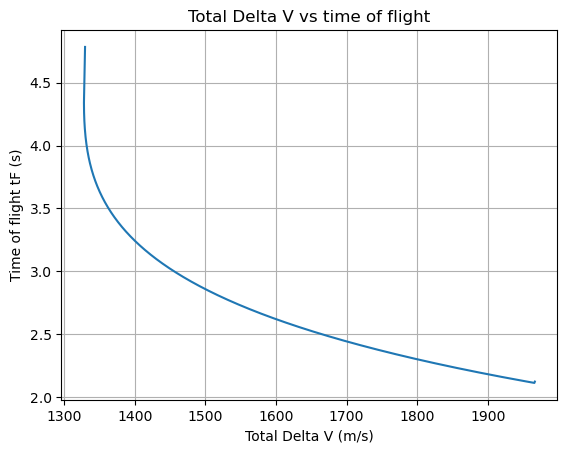

In [80]:
pio.renderers.default = "png"
plt.figure()
plt.plot(deltav_tot_m, tartF_ms/86400)
plt.ylabel('Time of flight tF (s)')
plt.xlabel('Total Delta V (m/s)')
plt.title('Total Delta V vs time of flight')
plt.grid(True)
plt.show()